In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
titles  = pd.read_csv("titles.csv")
titles

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"comedy, family, animation, action, fantasy, ho...",US,26,tt0850645,8.6,1092,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,Not Rated,78,"action, drama, war, western, comedy, european",US,0,tt0017925,8.2,89766,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,Not Rated,171,"romance, war, drama",US,0,tt0036868,8.1,63026,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,Not Rated,92,"comedy, drama, romance",US,0,tt0032599,7.8,57835,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,Not Rated,94,"thriller, drama, romance",US,0,tt0042593,7.9,30924,8.273,7.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9644,tm822572,Gun and a Hotel Bible,MOVIE,"Based on the original play, Gun and a Hotel Bi...",2021,Not Rated,58,drama,Unknown,0,tt10661500,4.0,142,0.954,6.5
9645,tm510327,Lily Is Here,MOVIE,Dallas and heroin have one thing in common: Du...,2021,Not Rated,93,drama,US,0,tt7672388,5.3,20,1.406,6.0
9646,tm1079144,Jay Nog: Something from Nothing,MOVIE,Something From Nothing takes you on a stand-up...,2021,Not Rated,55,comedy,US,0,tt15041600,5.9,460,0.600,6.0
9647,tm847725,Chasing,MOVIE,A cop from Chennai sets out to nab a dreaded d...,2021,Not Rated,116,crime,IN,0,Unknown,5.9,460,1.960,6.0


In [5]:
credits = pd.read_csv("credits.csv")
credits

,person_id,id,name,character,role
0,59401,ts20945,Joe Besser,Joe,ACTOR
1,31460,ts20945,Moe Howard,Moe,ACTOR
2,31461,ts20945,Larry Fine,Larry,ACTOR
3,21174,tm19248,Buster Keaton,Johnny Gray,ACTOR
4,28713,tm19248,Marion Mack,Annabelle Lee,ACTOR
...,...,...,...,...,...
124172,1938589,tm1054116,Sangam Shukla,Madhav,ACTOR
124173,1938565,tm1054116,Vijay Thakur,Sanjay Thakur,ACTOR
124174,728899,tm1054116,Vanya Wellens,Budhiya,ACTOR
124175,1938620,tm1054116,Vishwa Bhanu,Gissu,ACTOR


In [29]:
titles.info()
titles.describe()
titles.isnull().sum()
print(titles.columns)
print("Title duplicates:", titles.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9649 entries, 0 to 9648
Data columns (total 15 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   id                    9649 non-null   object 
 1   title                 9649 non-null   object 
 2   type                  9649 non-null   object 
 3   description           9649 non-null   object 
 4   release_year          9649 non-null   int64  
 5   age_certification     9649 non-null   object 
 6   runtime               9649 non-null   int64  
 7   genres                9649 non-null   object 
 8   production_countries  9649 non-null   object 
 9   seasons               9649 non-null   int64  
 10  imdb_id               9649 non-null   object 
 11  imdb_score            9649 non-null   float64
 12  imdb_votes            9649 non-null   int64  
 13  tmdb_popularity       9649 non-null   float64
 14  tmdb_score            9649 non-null   float64
dtypes: float64(3), int64(

In [48]:
credits.info()
print(credits.columns)
print(credits.describe())
print("credits null values\n",credits.isnull().sum())
print("credits duplicates\n",credits.duplicated().sum())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 124177 entries, 0 to 124176
Data columns (total 5 columns):
 #   Column     Non-Null Count   Dtype 
---  ------     --------------   ----- 
 0   person_id  124177 non-null  int64 
 1   id         124177 non-null  object
 2   name       124177 non-null  object
 3   character  124177 non-null  object
 4   role       124177 non-null  object
dtypes: int64(1), object(4)
memory usage: 4.7+ MB
Index(['person_id', 'id', 'name', 'character', 'role'], dtype='object')
          person_id
count  1.241770e+05
mean   4.065881e+05
std    5.617241e+05
min    1.000000e+00
25%    3.898800e+04
50%    1.339490e+05
75%    5.712850e+05
max    2.371153e+06
credits null values
 person_id    0
id           0
name         0
character    0
role         0
dtype: int64
credits duplicates
 0


In [64]:
titles = titles.drop_duplicates(subset="id")
titles

,id,title,type,description,release_year,age_certification,runtime,genres,production_countries,seasons,imdb_id,imdb_score,imdb_votes,tmdb_popularity,tmdb_score
0,ts20945,The Three Stooges,SHOW,The Three Stooges were an American vaudeville ...,1934,TV-PG,19,"comedy, family, animation, action, fantasy, ho...",US,26,tt0850645,8.6,1092,15.424,7.6
1,tm19248,The General,MOVIE,"During America’s Civil War, Union spies steal ...",1926,Not Rated,78,"action, drama, war, western, comedy, european",US,0,tt0017925,8.2,89766,8.647,8.0
2,tm82253,The Best Years of Our Lives,MOVIE,It's the hope that sustains the spirit of ever...,1946,Not Rated,171,"romance, war, drama",US,0,tt0036868,8.1,63026,8.435,7.8
3,tm83884,His Girl Friday,MOVIE,"Hildy, the journalist former wife of newspaper...",1940,Not Rated,92,"comedy, drama, romance",US,0,tt0032599,7.8,57835,11.270,7.4
4,tm56584,In a Lonely Place,MOVIE,An aspiring actress begins to suspect that her...,1950,Not Rated,94,"thriller, drama, romance",US,0,tt0042593,7.9,30924,8.273,7.6
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9644,tm822572,Gun and a Hotel Bible,MOVIE,"Based on the original play, Gun and a Hotel Bi...",2021,Not Rated,58,drama,Unknown,0,tt10661500,4.0,142,0.954,6.5
9645,tm510327,Lily Is Here,MOVIE,Dallas and heroin have one thing in common: Du...,2021,Not Rated,93,drama,US,0,tt7672388,5.3,20,1.406,6.0
9646,tm1079144,Jay Nog: Something from Nothing,MOVIE,Something From Nothing takes you on a stand-up...,2021,Not Rated,55,comedy,US,0,tt15041600,5.9,460,0.600,6.0
9647,tm847725,Chasing,MOVIE,A cop from Chennai sets out to nab a dreaded d...,2021,Not Rated,116,crime,IN,0,Unknown,5.9,460,1.960,6.0


In [66]:
text_columns = ["title", "description"]
for col in text_columns:
    titles[col] = titles[col].astype("string").str.strip()
text_columns

['title', 'description']

In [100]:
titles["release_year"]=pd.to_numeric(
    titles["release_year"],errors='coerce'
)
titles["runtime"]=pd.to_numeric(
    titles["runtime"],errors='coerce'
)
titles["imdb_score"] = pd.to_numeric(
    titles["imdb_score"],errors="coerce"
)
titles["imdb_votes"] = pd.to_numeric(
    titles["imdb_votes"],errors="coerce"
)

In [102]:
# Movies vs shows per release year
titles.groupby(["release_year","type"]).size().unstack(fill_value=0)
# Top 10 highest-rated titles with at least 10,000 votes
(titles[titles.imdb_votes > 10_000].nlargest(10, "imdb_score")[["title","release_year","imdb_score"]])
# Average rating by age certification
titles.groupby("age_certification")["imdb_score"].mean().sort_values()
# Genres are comma-separated text, so split and explode them
genres = (titles.assign(genre=titles["genres"].str.split(", "))
                .explode("genre"))
genres["genre"].value_counts().head(10)

genre
drama            4682
comedy           2943
thriller         2114
action           1809
romance          1739
crime            1242
documentation    1065
horror           1063
family            739
european          708
Name: count, dtype: int64

In [109]:
# Most frequent actors
credits[credits.role=="ACTOR"]["name"].value_counts().head(10)
# Join credits to titles on the shared 'id' column
full=credits.merge(titles,on="id",how="left")
# Directors of the highest-rated titles
(full[full.role=="DIRECTOR"]
    .groupby("name")["imdb_score"].agg(["mean","count"])
    .query("count>=3")
    .sort_values("mean",ascending=False)
    .head(10))

,mean,count
name,,
Rocco Urbisci,8.400000,3
Tony Charmoli,8.140000,5
Yin Tao,8.000000,3
Jeffrey Schwarz,7.800000,4
Mel Gibson,7.800000,3
Satyajit Ray,7.733333,3
Joel Coen,7.733333,3
Rituparno Ghosh,7.700000,4
Buster Keaton,7.666667,3


In [ ]:
np.mean(titles["runtime"])
np.median(titles["imdb_score"])
np.percentile(titles["runtime"],[25,50,75])
# Correlation between rating columns
titles[["imdb_score","tmdb_score","imdb_votes","tmdb_popularity"]].corr()
# Add a column: bucket titles into decades
titles["decade"]=(titles["release_year"]//10)*10

In [124]:
titles["type"].value_counts()

type
MOVIE    8344
SHOW     1305
Name: count, dtype: int64

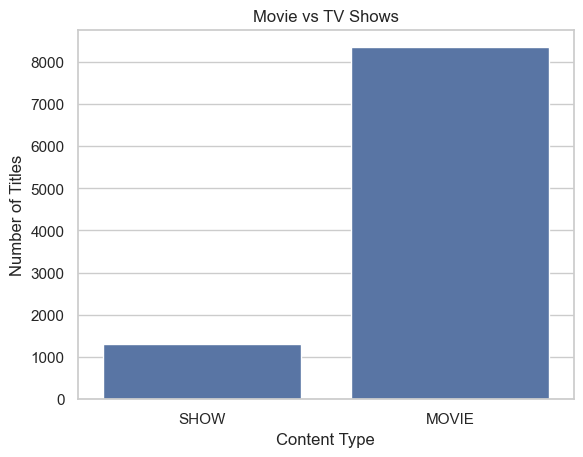

In [205]:
sns.countplot(data=titles,x="type")
plt.title("Movie vs TV Shows")
plt.xlabel("Content Type")
plt.ylabel("Number of Titles")
plt.show()

In [134]:
yearly_content=(
    titles.groupby("release_year")
    .size()
    .reset_index(name="total_titles")
)
print(yearly_content)

     release_year  total_titles
0            1912             1
1            1914             2
2            1915             5
3            1916             2
4            1917             1
..            ...           ...
105          2018           660
106          2019           780
107          2020           658
108          2021           799
109          2022            85

[110 rows x 2 columns]


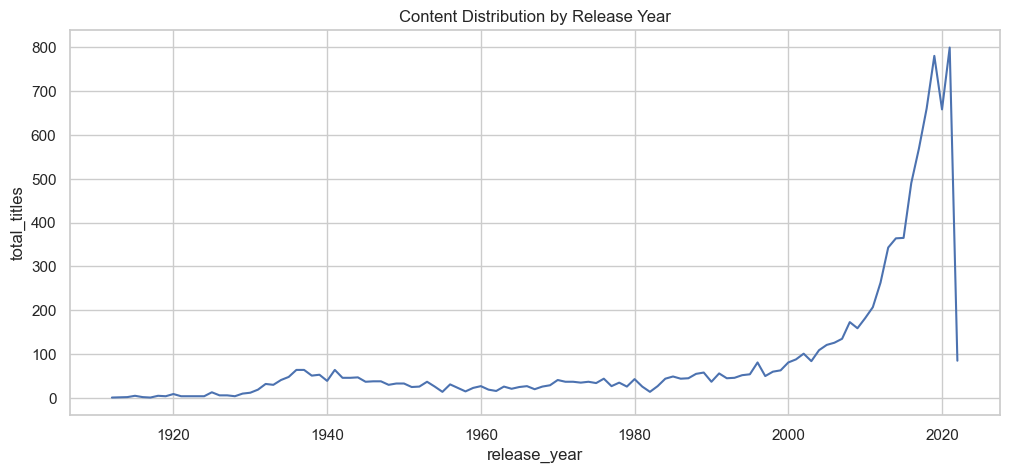

In [204]:
plt.figure(figsize=(12,5))
sns.lineplot(
    data=yearly_content,
    x="release_year",
    y="total_titles"
)
plt.title("Content Distribution by Release Year")
plt.show()

In [141]:
titles["imdb_score"].mean()

5.990340967975956

In [144]:
titles[["title","type","release_year","imdb_score"]].sort_values("imdb_score",ascending=False).head(10)

,title,type,release_year,imdb_score
8971,Pawankhind,MOVIE,2022,9.9
7684,Water Helps the Blood Run,SHOW,2019,9.7
8944,Couple of Mirrors,SHOW,2021,9.5
7328,The Chosen,SHOW,2019,9.4
9251,Tari Sathe,MOVIE,2021,9.4
9400,Pazhagiya Naatkal,MOVIE,2021,9.3
5075,Subaru Launch Control,SHOW,2013,9.3
8889,Jai Bhim,MOVIE,2021,9.3
8036,Alexander Babu: Alex in Wonderland,MOVIE,2019,9.2
7931,Quota,MOVIE,2020,9.2


In [146]:
top_people=(credits.groupby("name").size().sort_values(ascending=False).head(10))
print(top_people)

name
George 'Gabby' Hayes    49
Roy Rogers              45
Bess Flowers            44
Joseph Kane             41
Gene Autry              40
Sam Newfield            38
Nassar                  37
Charles King            35
Herman Hack             35
Jay Chapman             34
dtype: int64


In [148]:
actors=credits[credits["role"]=="ACTOR"]
actors["name"].value_counts().head(10)

name
George 'Gabby' Hayes    49
Roy Rogers              45
Bess Flowers            44
Gene Autry              40
Nassar                  37
Charles King            35
Herman Hack             35
Earl Dwire              34
George Morrell          34
Forrest Taylor          34
Name: count, dtype: int64

In [151]:
directors=credits[credits["role"]=='DIRECTOR']
directors["name"].value_counts().head(10)

name
Joseph Kane           41
Sam Newfield          38
Jay Chapman           34
Lesley Selander       22
Harry L. Fraser       21
John English          21
William Nigh          20
Manny Rodriguez       17
Robert N. Bradbury    17
Brian Volk-Weiss      16
Name: count, dtype: int64

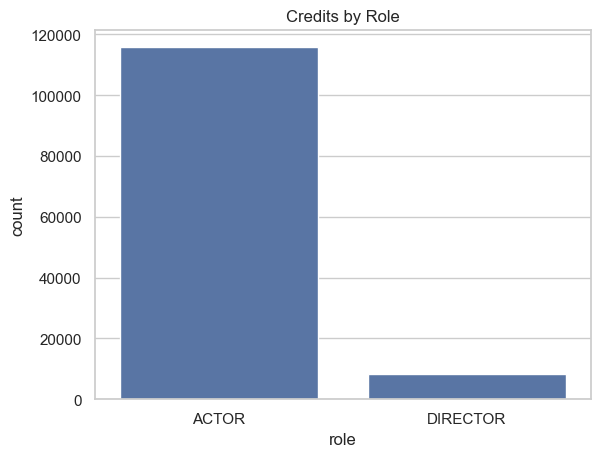

In [203]:
sns.countplot(data=credits,x='role')
plt.title("Credits by Role")
plt.show()

In [169]:
countries = titles[
    ["id", "production_countries"]
].explode(
    "production_countries"
)

countries["production_countries"].value_counts().head(10)

production_countries
US         4783
IN         1033
GB          666
Unknown     665
CA          317
JP          172
AU          143
XX          113
CN          105
FR           92
Name: count, dtype: int64

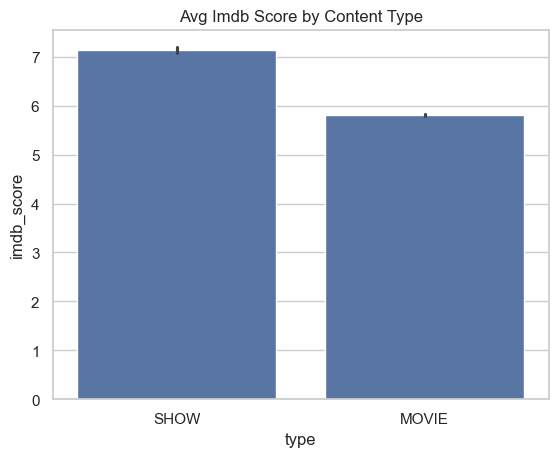

In [202]:
sns.barplot(data=titles,x="type",y="imdb_score")
plt.title("Avg Imdb Score by Content Type")
plt.show()

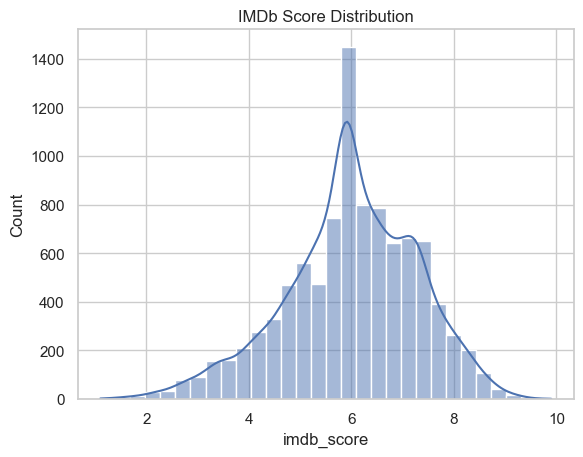

In [198]:
sns.histplot(titles["imdb_score"], bins=30, kde=True)
plt.title("IMDb Score Distribution")
plt.show()

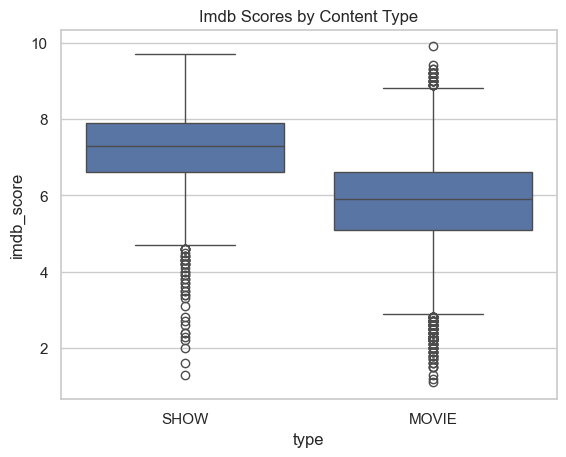

In [200]:
sns.boxplot(data=titles,x="type",y="imdb_score")
plt.title("Imdb Scores by Content Type")
plt.show()

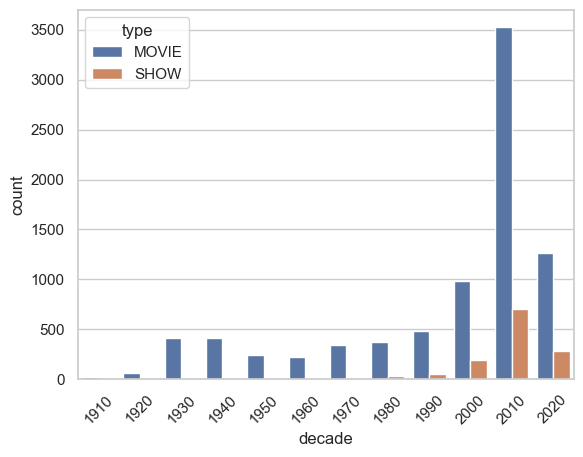

In [192]:
sns.countplot(data=titles, x="decade", hue="type")
plt.xticks(rotation=45)
plt.show()

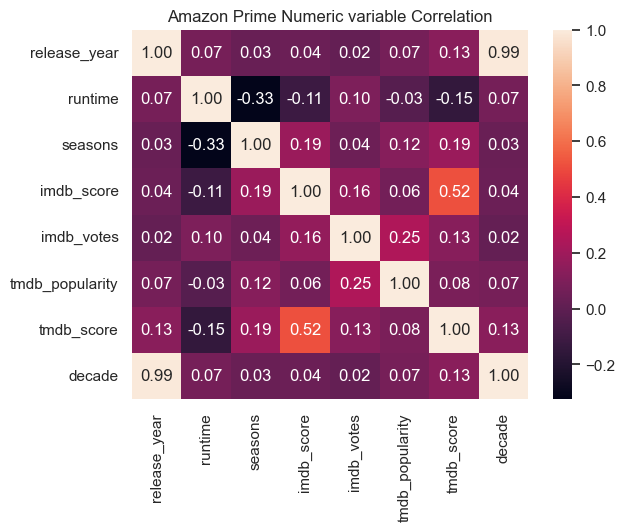

In [201]:
correlation=titles.corr(numeric_only=True)
sns.heatmap(correlation,annot=True,fmt=".2f")
plt.title("Amazon Prime Numeric variable Correlation")
plt.show()

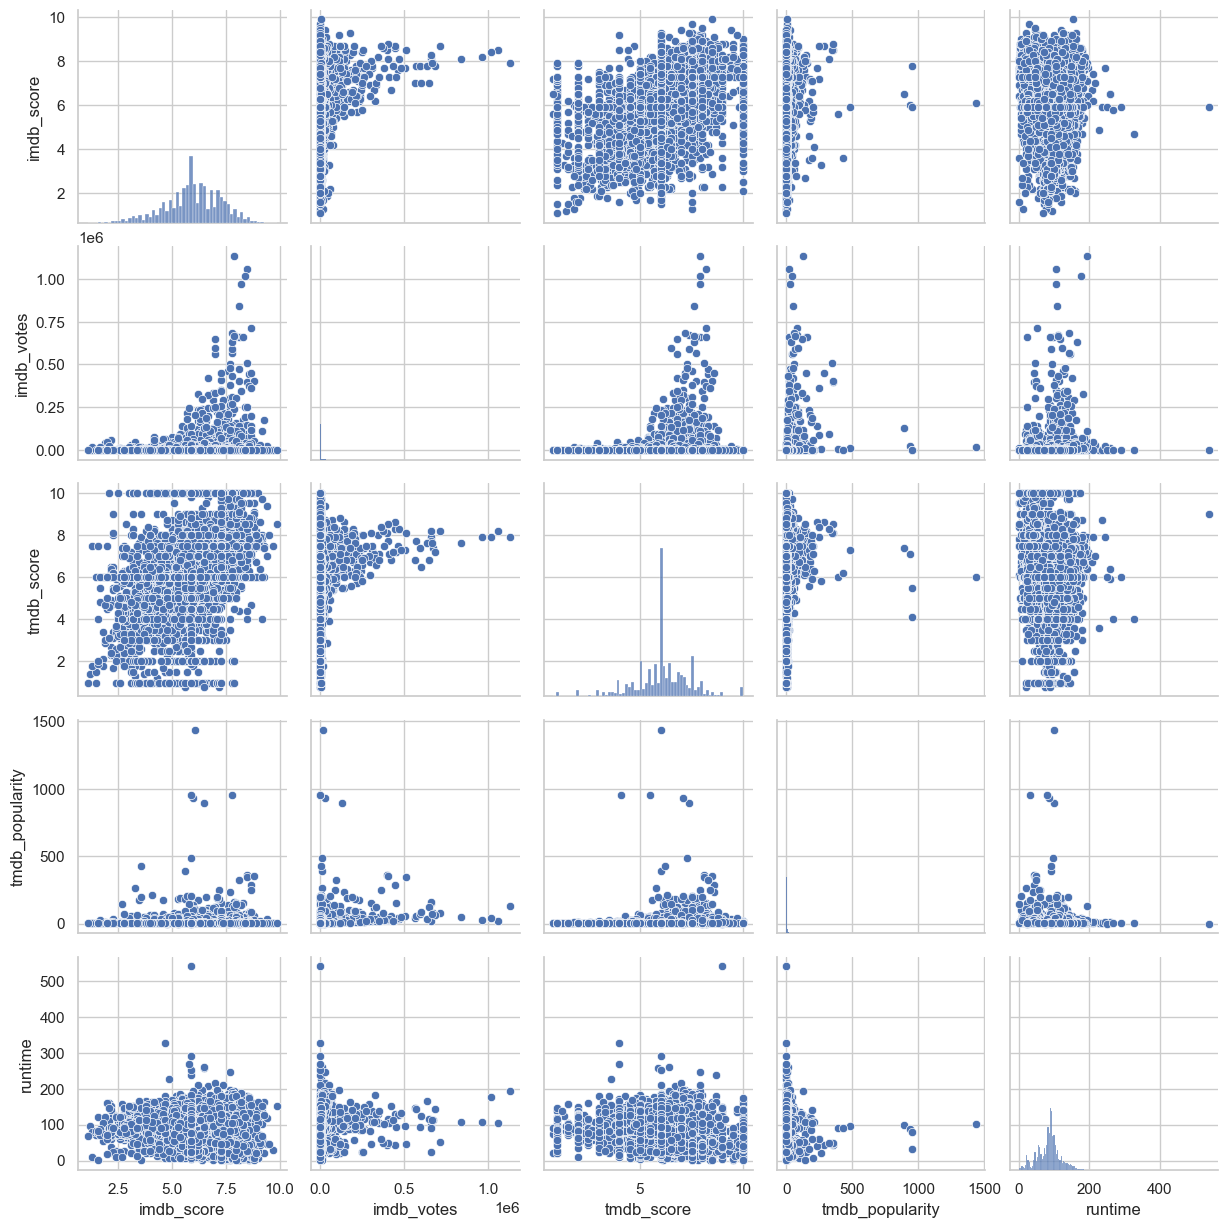

In [190]:
sns.pairplot(titles[["imdb_score","imdb_votes","tmdb_score","tmdb_popularity","runtime"]].dropna())
plt.show()

In [211]:
titles.to_csv("titles_cleaned.csv",index=False)
credits.to_csv("credits_cleaned.csv",index=False)